# Similarity & Retrieval Experiment

## Objective

Study how embedded document chunks are compared and ranked for semantic
retrieval.

The experiment uses:

- The existing ZCompanyLLC HR corpus
- The existing M3 `DocumentChunk` representation
- The M4.3 selected embedding model: `BAAI/bge-small-en-v1.5`

The experiment investigates:

1. Cosine similarity
2. Vector normalization
3. Dot-product equivalence for normalized vectors
4. Top-K retrieval
5. Similarity score distributions
6. Retrieval behavior across different query types
7. The limitations of fixed Top-K retrieval
8. The role of similarity thresholds

This experiment does not introduce a production vector store.

The goal is to establish the retrieval semantics and evaluation behavior
before implementing the persistent vector-store abstraction in M4.5.

In [1]:
from pathlib import Path
import sys
import time

import numpy as np
from sentence_transformers import SentenceTransformer

PYTHON_SRC = Path("../../python/src").resolve()

if str(PYTHON_SRC) not in sys.path:
    sys.path.insert(0, str(PYTHON_SRC))

from rag_platform.chunking.recursive import RecursiveChunker
from rag_platform.connectors.filesystem import FilesystemConnector
from rag_platform.domain.models import (
    DocumentSource,
    SourceType,
)
from rag_platform.domain.types import SourceID, TenantID
from rag_platform.parsers.markdown import MarkdownParser
from rag_platform.parsers.pdf import PDFParser
from rag_platform.parsers.text import TextParser

/Users/kashyaprajpurohit/myGitHubRepos/kr-ai-workshop/rag-platform/python/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
DATA_ROOT = Path(
    "../../data/raw/ZCompanyLLC"
).resolve()

source = DocumentSource(
    id=SourceID("zcompanyllc-hr"),
    tenant_id=TenantID("zcompanyllc"),
    source_type=SourceType.FILE,
    uri=str(DATA_ROOT),
)

connector = FilesystemConnector(source)

documents = connector.read()

print(f"Documents discovered: {len(documents)}")


Documents discovered: 85


In [4]:
parsers = {
    "markdown": MarkdownParser(),
    "pdf": PDFParser(),
    "txt": TextParser(),
}

parsed_documents = [
    parsers[document.format.value].parse(document)
    for document in documents
]

print(f"Documents parsed: {len(parsed_documents)}")

Documents parsed: 85


In [5]:
chunker = RecursiveChunker(
    chunk_size=1000,
    chunk_overlap=150,
)

chunks = []

for document in parsed_documents:
    chunks.extend(chunker.chunk(document))

print(f"Document chunks: {len(chunks)}")

Document chunks: 88


In [6]:
MODEL_NAME = "BAAI/bge-small-en-v1.5"

model = SentenceTransformer(MODEL_NAME)

chunk_texts = [
    chunk.text
    for chunk in chunks
]

document_embeddings = model.encode(
    chunk_texts,
    convert_to_numpy=True,
    show_progress_bar=True,
)

print("Model:", MODEL_NAME)
print("Embedding shape:", document_embeddings.shape)

Batches: 100%|██████████| 3/3 [00:00<00:00,  5.29it/s]

Model: BAAI/bge-small-en-v1.5
Embedding shape: (88, 384)


In [7]:
def cosine_similarity(
    query_vector: np.ndarray,
    document_vectors: np.ndarray,
) -> np.ndarray:
    query_norm = np.linalg.norm(query_vector)

    document_norms = np.linalg.norm(
        document_vectors,
        axis=1,
    )

    return (
        document_vectors @ query_vector
    ) / (
        document_norms * query_norm
    )

Lets create our first query 

In [8]:
query = "How many days can an employee based in India work remotely each week?"

query_embedding = model.encode(
    [query],
    convert_to_numpy=True,
)[0]

scores = cosine_similarity(
    query_embedding,
    document_embeddings,
)

print("Number of scores:", len(scores))
print("Min score:", scores.min())
print("Max score:", scores.max())

Number of scores: 88
Min score: 0.46835437
Max score: 0.8432036


Understand the score distribution 

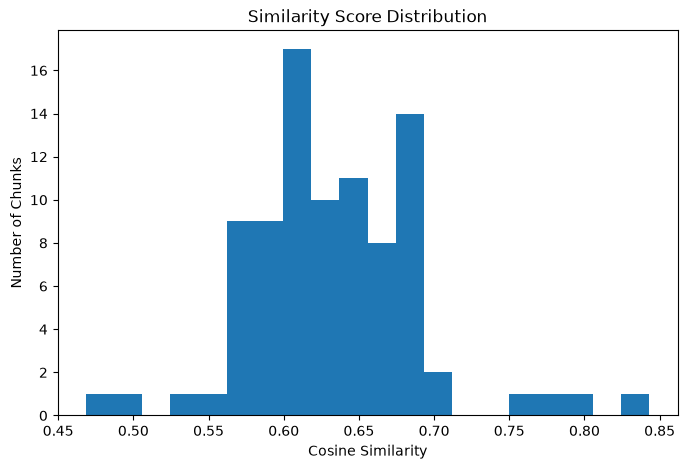

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    scores,
    bins=20,
)

plt.xlabel("Cosine Similarity")
plt.ylabel("Number of Chunks")
plt.title("Similarity Score Distribution")

plt.show()

Rank al the Chunks 

In [10]:
ranked_indices = np.argsort(scores)[::-1]

for rank, index in enumerate(
    ranked_indices[:10],
    start=1,
):
    print(
        f"{rank:2d}. "
        f"{scores[index]:.4f} | "
        f"{chunks[index].chunk_id}"
    )

 1. 0.8432 | 92229214bff5812084d99491aa93721c95154cad86f46223b18f3a4666b76f3b
 2. 0.7885 | 249509402ad2ba740e346b1fa0974d8e7f76cb7391a2186741b3b6805b81477a
 3. 0.7808 | 92b982d144b0837e053302fe5fdf540e354492d96bf7a446334cda17f1f8db3e
 4. 0.7532 | a55615575205e7fb0a8c12d4120ab4982716716db924db669cacaa70a4c64c5c
 5. 0.7003 | 27df9a355b50a0d029395e167024b072442cca946b16149039b5677b179bdfb7
 6. 0.6935 | 9e8df724e4c0ee2039397968bfafacc0c3acbd7a4854b7d5d335886642d2ceec
 7. 0.6917 | 018de2cb477b175a28870ea662b01ecc1f9c20283fd8b9c26f6e427f533a4baa
 8. 0.6905 | 1fd5777f55f93a7432c4122faa93d7b05c1a1b3229dc5a7793de2b340260fba6
 9. 0.6901 | 1c53d36ab37a1337b717e8049b274e5a024e8f7c95a7aa591b75f18d515b1af2
10. 0.6896 | 700c77d8f4274fed63681790998451dbb2c1f07254974e77219d6f2dc197fa41


Inspect - Top 5 

In [11]:
for rank, index in enumerate(
    ranked_indices[:5],
    start=1,
):
    chunk = chunks[index]

    print("=" * 100)
    print(f"Rank:  {rank}")
    print(f"Score: {scores[index]:.4f}")
    print(f"Chunk: {chunk.chunk_id}")
    print(f"Doc:   {chunk.document_id}")
    print()
    print(chunk.text[:600])

Rank:  1
Score: 0.8432
Chunk: 92229214bff5812084d99491aa93721c95154cad86f46223b18f3a4666b76f3b
Doc:   58c81401f73328db561305ebac315f8922fb4e040f7b9556b6c99b872cc8d2bb

# India Work From Home Policy

Employees based in India may request up to 2 regular remote-working days per week.

Temporary work from another country:
- Must be recorded before travel.
- Requires manager approval.
- Germany- and India-based employees are normally subject to host-country leave/holiday rules while temporarily working abroad.
- Sweden-based employees remain under Swedish HQ policy globally.

Remote work does not itself change an employee's permanent base location.

Rank:  2
Score: 0.7885
Chunk: 249509402ad2ba740e346b1fa0974d8e7f76cb7391a2186741b3b6805b81477a
Doc:   c35ef33d207779ba8a8eafdbcb46bb925fb0c9edf33f2c0356cb33770ffd70f2

# Germany Work From Home Policy

Employees based in Germany may request up to 2 regular remote-working days per week.

Temporary work from another country:
- Must be recorded befo

Current observation
For the India-specific query:

88 scores
Range: 0.468 → 0.843
Rank #1 = India WFH Policy — 0.8432
Rank #2 = Germany WFH — 0.7885
Rank #3 = Sweden WFH — 0.7808

So our basic cosine-ranking implementation is working.

One useful observation:
There is no obvious universal cutoff like 0.7 that we can declare relevant yet.

For this query, even rank #5 has 0.7003, and whether that chunk belongs in the answer context is a semantic judgment. We'll investigate thresholds later rather than invent one now.

Cosine vs Dot Product 

In [12]:
query_norm = np.linalg.norm(query_embedding)
document_norms = np.linalg.norm(
    document_embeddings,
    axis=1,
)

print(f"Query norm: {query_norm:.6f}")
print(
    f"Document norms: "
    f"{document_norms.min():.6f} → "
    f"{document_norms.max():.6f}"
)

Query norm: 1.000000
Document norms: 1.000000 → 1.000000


In [13]:
dot_scores = document_embeddings @ query_embedding

max_difference = np.max(
    np.abs(scores - dot_scores)
)

print(f"Maximum difference: {max_difference:.10f}")

Maximum difference: 0.0000001192


Conclusion

For our current BGE-small setup:
normalized vectors
       ↓
cosine similarity ≈ dot product

That means a vector store supporting inner product / dot product search can implement the same ranking behavior for these normalized embeddings.

But: let's keep the platform abstraction expressed in terms of similarity, not expose "dot product" as a domain concept. The embedding model's normalization behavior is an implementation detail.

Top-K behavior

In [14]:
for k in [1, 3, 5, 10]:
    top_indices = np.argsort(scores)[::-1][:k]

    print(
        f"Top-{k}: "
        f"score range "
        f"{scores[top_indices[-1]]:.4f} → "
        f"{scores[top_indices[0]]:.4f}"
    )

Top-1: score range 0.8432 → 0.8432
Top-3: score range 0.7808 → 0.8432
Top-5: score range 0.7003 → 0.8432
Top-10: score range 0.6896 → 0.8432


In [15]:
for k in [1, 3, 5, 10]:
    print(f"\n--- Top-{k} ---")

    top_indices = np.argsort(scores)[::-1][:k]

    for rank, index in enumerate(top_indices, start=1):
        print(
            f"{rank}. "
            f"{scores[index]:.4f} | "
            f"{chunks[index].text[:100].replace(chr(10), ' ')}"
        )


--- Top-1 ---
1. 0.8432 | # India Work From Home Policy  Employees based in India may request up to 2 regular remote-working d

--- Top-3 ---
1. 0.8432 | # India Work From Home Policy  Employees based in India may request up to 2 regular remote-working d
2. 0.7885 | # Germany Work From Home Policy  Employees based in Germany may request up to 2 regular remote-worki
3. 0.7808 | # Sweden Work From Home Policy  Employees based in Sweden may request up to 2 regular remote-working

--- Top-5 ---
1. 0.8432 | # India Work From Home Policy  Employees based in India may request up to 2 regular remote-working d
2. 0.7885 | # Germany Work From Home Policy  Employees based in Germany may request up to 2 regular remote-worki
3. 0.7808 | # Sweden Work From Home Policy  Employees based in Sweden may request up to 2 regular remote-working
4. 0.7532 | # India Leave and Work Policy  **Fictional policy for the RAG demo.**  ## Annual leave - Standard an
5. 0.7003 | Employment Agreement — Priya Shah Emplo

Top-K vs Threshold

In [16]:
for threshold in [0.80, 0.75, 0.70, 0.65]:
    indices = np.where(scores >= threshold)[0]
    indices = indices[np.argsort(scores[indices])[::-1]]

    print(
        f"\nThreshold >= {threshold:.2f}: "
        f"{len(indices)} chunks"
    )

    for index in indices[:10]:
        print(
            f"{scores[index]:.4f} | "
            f"{chunks[index].text[:100].replace(chr(10), ' ')}"
        )


Threshold >= 0.80: 1 chunks
0.8432 | # India Work From Home Policy  Employees based in India may request up to 2 regular remote-working d

Threshold >= 0.75: 4 chunks
0.8432 | # India Work From Home Policy  Employees based in India may request up to 2 regular remote-working d
0.7885 | # Germany Work From Home Policy  Employees based in Germany may request up to 2 regular remote-worki
0.7808 | # Sweden Work From Home Policy  Employees based in Sweden may request up to 2 regular remote-working
0.7532 | # India Leave and Work Policy  **Fictional policy for the RAG demo.**  ## Annual leave - Standard an

Threshold >= 0.70: 5 chunks
0.8432 | # India Work From Home Policy  Employees based in India may request up to 2 regular remote-working d
0.7885 | # Germany Work From Home Policy  Employees based in Germany may request up to 2 regular remote-worki
0.7808 | # Sweden Work From Home Policy  Employees based in Sweden may request up to 2 regular remote-working
0.7532 | # India Leave and Work P

## Conclusions

- BGE-small produces normalized embeddings, making cosine similarity and
  dot product effectively equivalent for the current model configuration.
- Similarity scores provide a ranking signal but should not be interpreted
  using a universal relevance threshold.
- Increasing Top-K increases context coverage but also introduces less
  relevant chunks.
- Small changes in a similarity threshold can produce large changes in the
  number of retrieved chunks.
- For the prototype, retrieval will use fixed Top-K selection.
- A configurable score threshold may be introduced later after proper
  retrieval evaluation.
- The initial prototype retrieval configuration is Top-K = 5 with no
  similarity threshold.